# Modular Student Stress Pipeline
This notebook calls the refactored project parts under `src/` instead of embedding all logic in notebook cells.

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# Resolve project root whether notebook runs from repo root or notebooks/
project_root = Path.cwd()
if not (project_root / "backend").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

# Add both repo root and backend folder so internal modules using `import config` work.
backend_root = project_root / "backend"
for p in (project_root, backend_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from backend import config
from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, GradientBoostingModel

warnings.filterwarnings("ignore")
print("Modules loaded successfully.")

Modules loaded successfully.


In [2]:
# Initialize modular components
from backend.src.models.decision_tree_model import DecisionTreeModel


loader = DataLoader()
cleaner = DataCleaner()
engineer = FeatureEngineer()
converters = Converters()
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor()
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

models = [
    GradientBoostingModel(),
    DecisionTreeModel()
]

print("Components initialized.")

Components initialized.


In [3]:
# 1) Data ingestion
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


In [4]:
# 2) Data cleaning + 3) Feature engineering
df = cleaner.clean(df, config.NUMERIC_COLS, config.CATEGORICAL_COLS, config.TARGET)
df = engineer.engineer(df, config.DERIVED_COLS, config.TARGET, converters, config.TARGET_CATEGORY)

# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

print(df.shape)
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

(2842, 27)
stress_category
Low         773
Average    1195
High        874
Name: count, dtype: int64


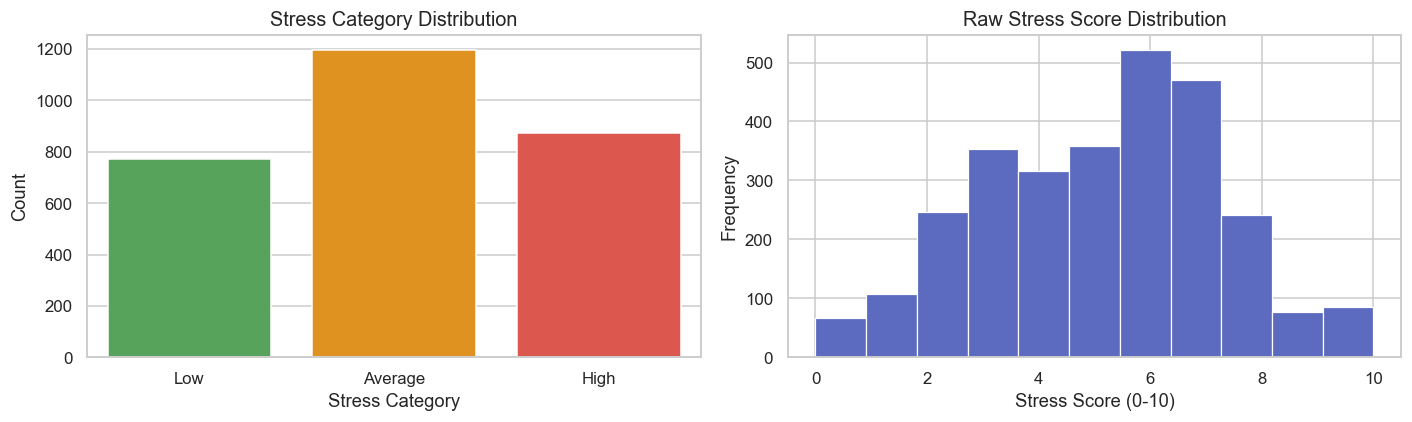

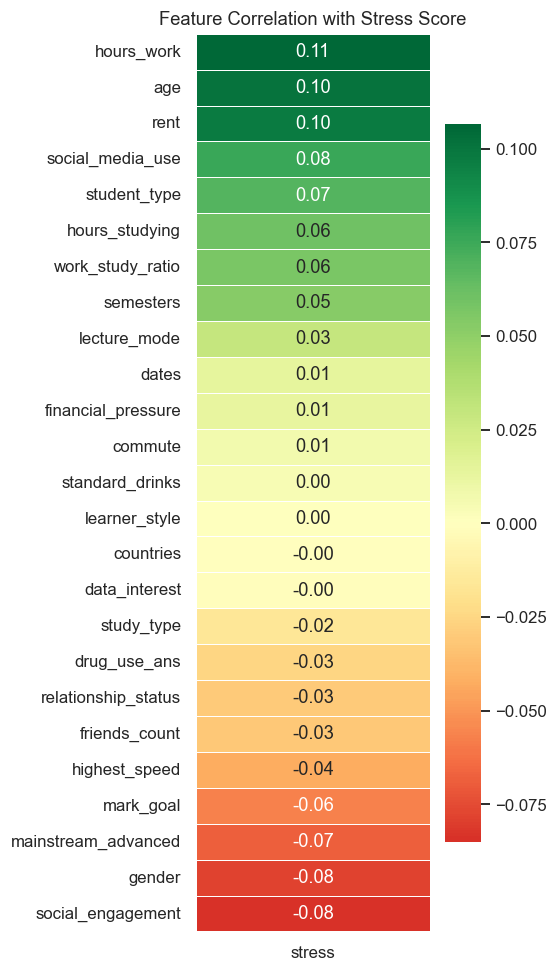

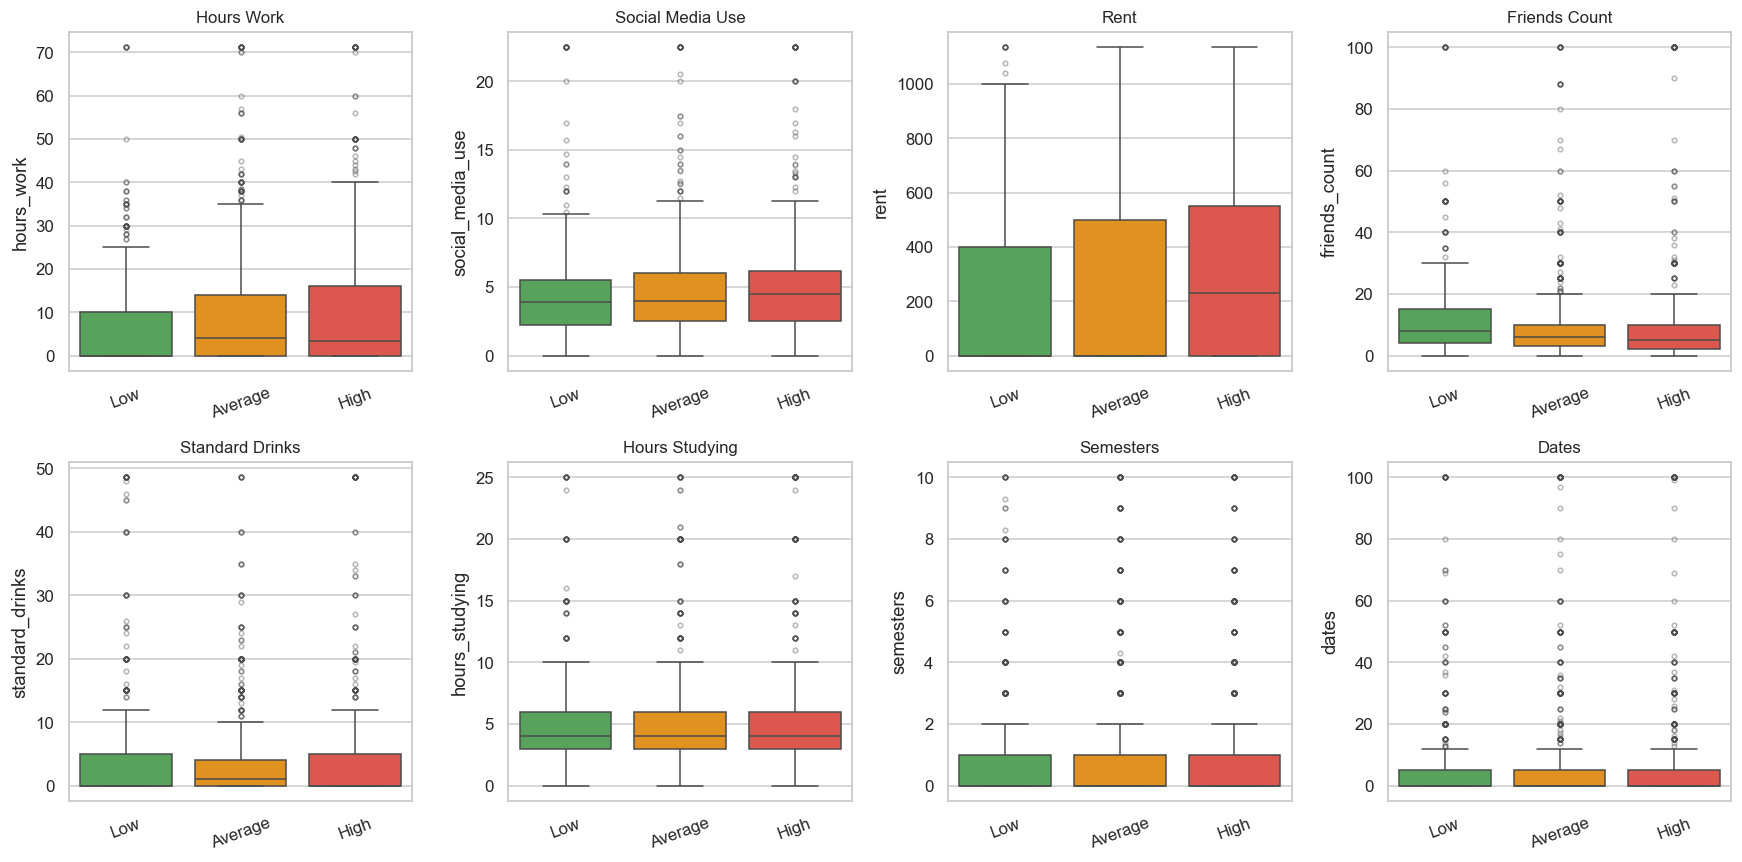

In [5]:
feature_cols = config.NUMERIC_COLS + config.DERIVED_COLS + config.CATEGORICAL_COLS
eda.run(df, df_eda, feature_cols, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

In [6]:
# 5) Use designated split files (train/validation/test) with 75/15/10 fallback creation
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

X_num = df[config.ALL_NUMERIC].copy()
X_cat = raw.loc[df.index, config.ALL_CATS].fillna("Unknown")
X_raw = pd.concat([X_num, X_cat], axis=1)
y_cat = df[config.TARGET_CATEGORY]

train_path = config.DATA_DIR / "train.csv"
validation_path = config.DATA_DIR / "validation.csv"
test_path = config.DATA_DIR / "test.csv"
required_cols = config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET_CATEGORY]

if train_path.exists() and validation_path.exists() and test_path.exists():
    train_df = pd.read_csv(train_path)
    validation_df = pd.read_csv(validation_path)
    test_df = pd.read_csv(test_path)

    missing = [
        c for c in required_cols
        if c not in train_df.columns or c not in validation_df.columns or c not in test_df.columns
    ]
    if missing:
        raise ValueError(f"Split files are missing required columns: {missing}")

    train_df = train_df[required_cols]
    validation_df = validation_df[required_cols]
    test_df = test_df[required_cols]
    print("Using existing split files: train.csv, validation.csv, test.csv")
else:
    X_train, X_temp, ycat_train, ycat_temp = train_test_split(
        X_raw,
        y_cat,
        test_size=1 - train_ratio,
        random_state=config.SEED,
        stratify=y_cat,
    )

    X_val, X_test, ycat_val, ycat_test = train_test_split(
        X_temp,
        ycat_temp,
        test_size=test_ratio / (test_ratio + validation_ratio),
        random_state=config.SEED,
        stratify=ycat_temp,
    )

    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    train_df = X_train.copy()
    train_df[config.TARGET_CATEGORY] = ycat_train.values
    train_df.to_csv(train_path, index=False)

    validation_df = X_val.copy()
    validation_df[config.TARGET_CATEGORY] = ycat_val.values
    validation_df.to_csv(validation_path, index=False)

    test_df = X_test.copy()
    test_df[config.TARGET_CATEGORY] = ycat_test.values
    test_df.to_csv(test_path, index=False)
    print("Created split files: train.csv, validation.csv, test.csv")

X_train = train_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_train = train_df[config.TARGET_CATEGORY]
X_val = validation_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_val = validation_df[config.TARGET_CATEGORY]
X_test = test_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_test = test_df[config.TARGET_CATEGORY]

X_train_t = pipeliner.fit_transform(X_train)
X_val_t = pipeliner.transform(X_val)
X_test_t = pipeliner.transform(X_test)

print(f"Train={len(X_train_t)} | Validation={len(X_val_t)} | Test={len(X_test_t)}")

Using existing split files: train.csv, validation.csv, test.csv
Train=2131 | Validation=426 | Test=285


In [7]:
# 6) Train models
for model in models:
    model.train(X_train_t, ycat_train.values, X_val_t, ycat_val.values)
    print(f"Trained: {model.get_name()}")


────────────────────────────────────────────────────
  Training: Gradient Boosting Model
────────────────────────────────────────────────────
  [Round 1/5]  n_estimators=100  train_acc=0.7396
  [Round 2/5]  n_estimators=200  train_acc=0.8395
  [Round 3/5]  n_estimators=300  train_acc=0.9057
Optimal training score reached (0.9057 >= 0.9).  Stopping early.

  Validation:  val_acc=0.3991  gap=0.5066  (tolerance=0.05)
 Validation gap too large.  Starting hyper-tuning ...
  [Hypertune 1/5]  RandomizedSearchCV (n_iter=20) ...
  Best params : {'subsample': 0.9, 'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.08}
  train_acc=0.6790  val_acc=0.4061  gap=0.2729
  [Hypertune 2/5]  RandomizedSearchCV (n_iter=20) ...
  Best params : {'subsample': 0.9, 'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.08}
  train_acc=0.6790  val_acc=0.4061  gap=0.2729
  [Hypertune 3/5]  RandomizedSearchCV (n_


  Gradient Boosting Model  |  Accuracy: 43.9%
              precision    recall  f1-score   support

         Low       0.44      0.27      0.34        77
     Average       0.45      0.65      0.53       120
        High       0.40      0.30      0.34        88

    accuracy                           0.44       285
   macro avg       0.43      0.41      0.40       285
weighted avg       0.43      0.44      0.42       285


  Decision Tree Model  |  Accuracy: 48.1%
              precision    recall  f1-score   support

         Low       0.45      0.32      0.38        77
     Average       0.50      0.66      0.57       120
        High       0.47      0.38      0.42        88

    accuracy                           0.48       285
   macro avg       0.47      0.45      0.45       285
weighted avg       0.48      0.48      0.47       285



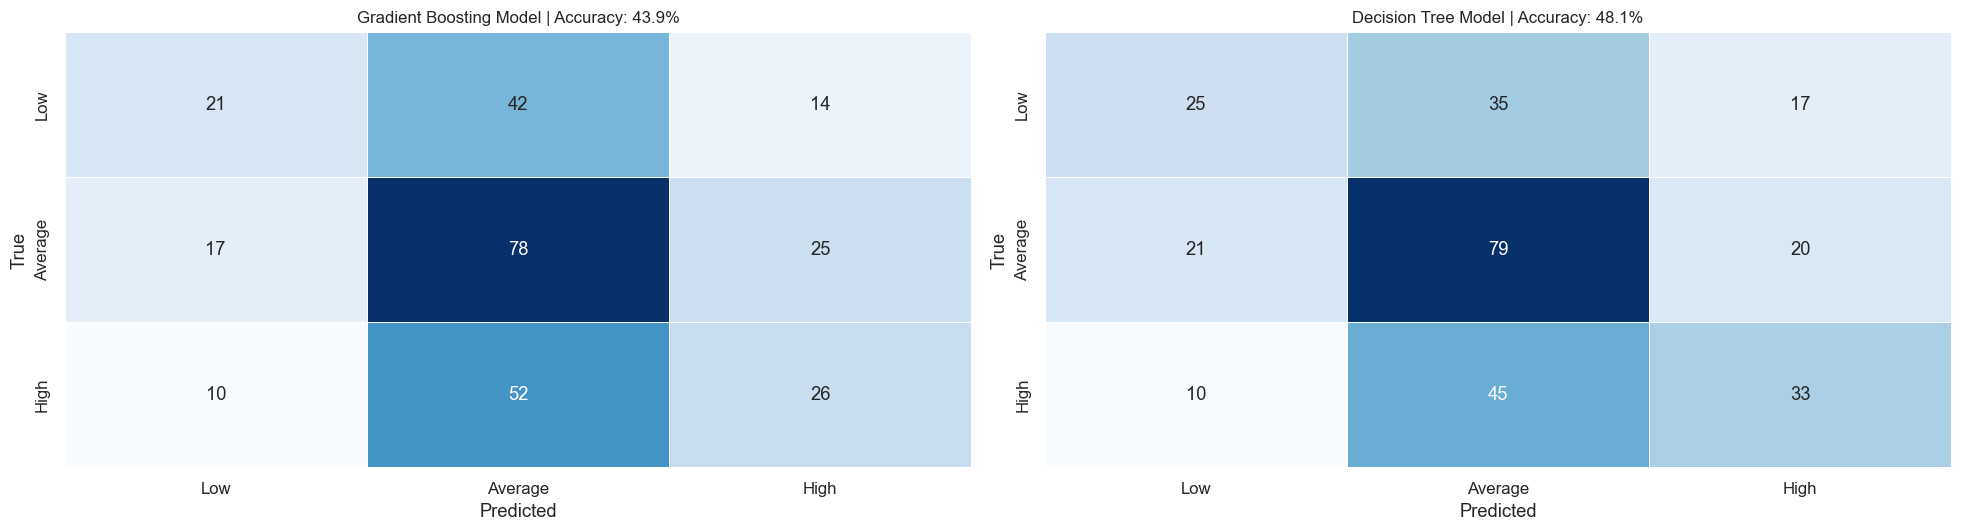

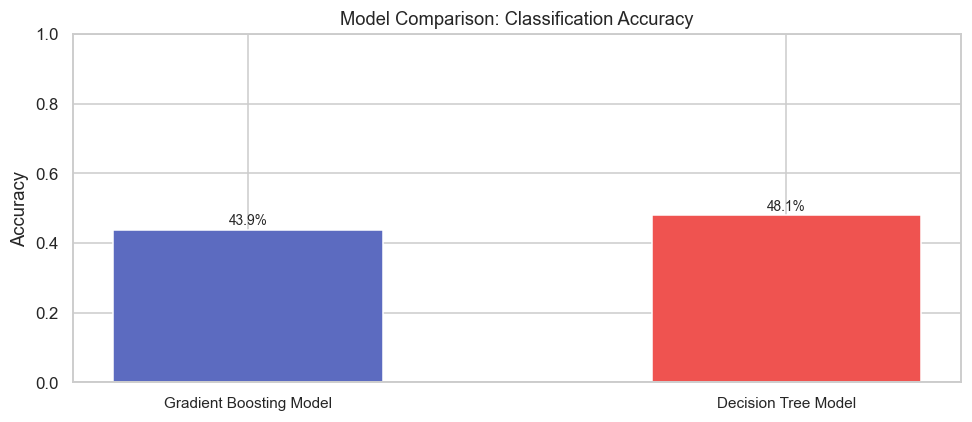

In [8]:
# 7) Evaluate
pred_cats = {m.get_name(): m.predict(X_test_t) for m in models}

class_reports = evaluator.classification_report_all(ycat_test.values, pred_cats, config.CATEGORY_ORDER)
evaluator.print_classification_reports(class_reports)

model_names = list(class_reports.keys())
accs = [class_reports[n]["accuracy"] for n in model_names]
visualizer.plot_confusion_matrices(class_reports, config.CATEGORY_ORDER)
visualizer.plot_model_comparison(model_names, accs)

In [35]:
# 8) Save artifacts
config.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
for model in models:
    model.save(config.SAVED_MODELS_DIR / config.MODEL_FILE_MAP[model.get_name()])
pipeliner.save(config.PIPERLINER_FILE)
print("Saved models and pipeliner.")

KeyError: 'Gradient Boosting Model'

In [ ]:
# 9) Generate profile and predict
generated_profile = profile_generator.generate_profile(df, seed=config.SEED, mode="random")
profile_df = profile_generator.build(generated_profile)
results = predictor.predict(profile_df, models, pipeliner)
predictor.print_results(results)
results

  STUDENT STRESS PREDICTION
  Gradient Boosting     : Average


[{'model_name': 'Gradient Boosting', 'category': 'Average'}]

In [ ]:
Test